import the Pandas library to handle the dataset and load the results.csv file into a DataFrame.

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("results.csv")

# Display the first 5 rows to ensure it loaded correctly
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


Basic Exploration
Calculate the matches in dataset, earliest and latest year, unique countries and most frequent home team.

In [3]:
# 1. How many matches are in the dataset?
total_matches = df.shape[0]
print(f"Total matches: {total_matches}")

# 2. What is the earliest and latest year in the data?
# Convert date to datetime for safe extraction
df["date"] = pd.to_datetime(df["date"])
earliest_year = df["date"].dt.year.min()
latest_year = df["date"].dt.year.max()
print(f"Earliest year: {earliest_year}, Latest year: {latest_year}")

# 3. How many unique countries are there?
# Note: This counts the unique countries where matches were played. 
unique_countries = df["country"].nunique()
print(f"Unique host countries: {unique_countries}")

# 4. Which team appears most frequently as home team?
most_frequent_home = df["home_team"].value_counts().head(1)
print(f"Most frequent home team:\n{most_frequent_home}")

Total matches: 49287
Earliest year: 1872, Latest year: 2026
Unique host countries: 269
Most frequent home team:
home_team
Brazil    614
Name: count, dtype: int64


Goal Analysis
Calculate total goals, average goals, highest scoring match, home vs away,most common goals.

In [4]:
# Create total goals
df["total_goals"] = df["home_score"] + df["away_score"]

# 1. What is the average number of goals per match?
avg_goals = df["total_goals"].mean()
print(f"Average goals per match: {avg_goals:.2f}")

# 2. What is the highest scoring match?
highest_scoring_idx = df["total_goals"].idxmax()
highest_scoring_match = df.loc[highest_scoring_idx]
print("\nHighest scoring match details:")
print(f"{highest_scoring_match['home_team']} {highest_scoring_match['home_score']} - {highest_scoring_match['away_score']} {highest_scoring_match['away_team']}")
print(f"Total Goals: {highest_scoring_match['total_goals']}")

# 3. Are more goals scored at home or away?
total_home_goals = df["home_score"].sum()
total_away_goals = df["away_score"].sum()

print(f"\nTotal Home Goals: {total_home_goals}")
print(f"Total Away Goals: {total_away_goals}")
if total_home_goals > total_away_goals:
    print("Conclusion: More goals are scored at home.")
else:
    print("Conclusion: More goals are scored away.")

# 4. What is the most common total goals value?
most_common_goals = df["total_goals"].mode()[0]
print(f"\nMost common total goals value: {most_common_goals}")

Average goals per match: 2.94

Highest scoring match details:
Australia 31.0 - 0.0 American Samoa
Total Goals: 31.0

Total Home Goals: 86426.0
Total Away Goals: 58192.0
Conclusion: More goals are scored at home.

Most common total goals value: 2.0


Match Results
Calculate match outcome, percentage of home wins, home advantage, most wins historically.

In [5]:
# Create match outcome function
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(match_result, axis=1)

# 1. What percentage of matches are home wins?
win_percentages = df["result"].value_counts(normalize=True) * 100
home_win_pct = win_percentages["Home Win"]
print(f"Percentage of home wins: {home_win_pct:.2f}%")

# 2. Does home advantage exist?
away_win_pct = win_percentages["Away Win"]
print(f"Percentage of away wins: {away_win_pct:.2f}%")
print("Conclusion: Yes, home advantage exists because the percentage of home wins is significantly higher than away wins.")

# 3. Which country has the most wins historically?
# Count home wins per team
home_wins = df[df["result"] == "Home Win"]["home_team"].value_counts()
# Count away wins per team
away_wins = df[df["result"] == "Away Win"]["away_team"].value_counts()

# Combine both and sort
total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)
most_wins_team = total_wins.index[0]
most_wins_count = total_wins.iloc[0]

print(f"\nTeam with the most wins historically: {most_wins_team} ({int(most_wins_count)} wins)")

Percentage of home wins: 48.91%
Percentage of away wins: 28.23%
Conclusion: Yes, home advantage exists because the percentage of home wins is significantly higher than away wins.

Team with the most wins historically: Brazil (670 wins)


Visualization
Create a histogram of goals,bar chart of outcomes and top 10 teams by total wins.

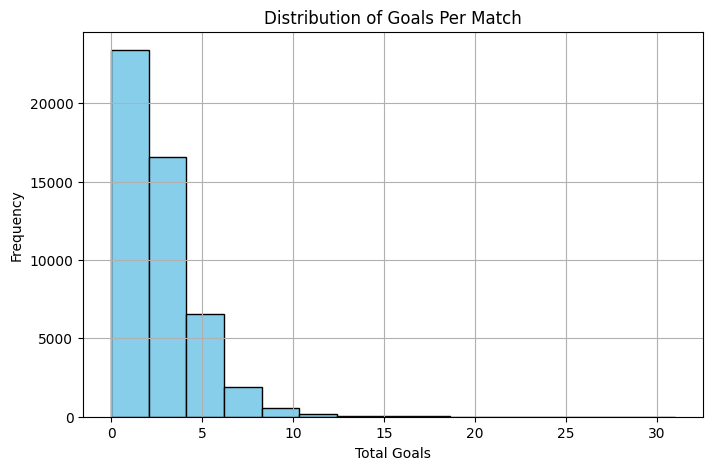

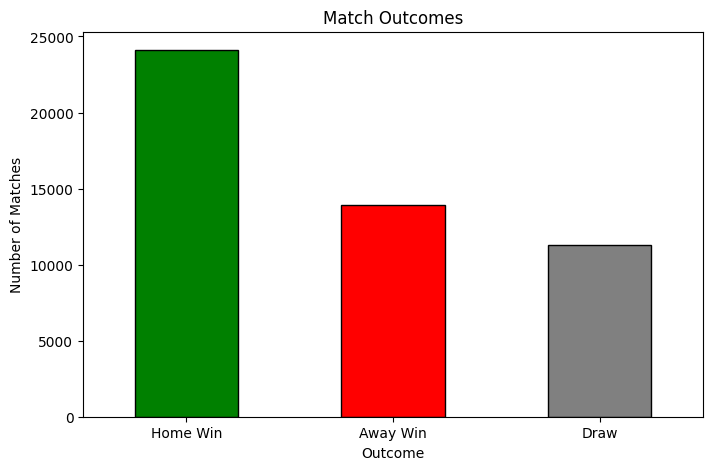

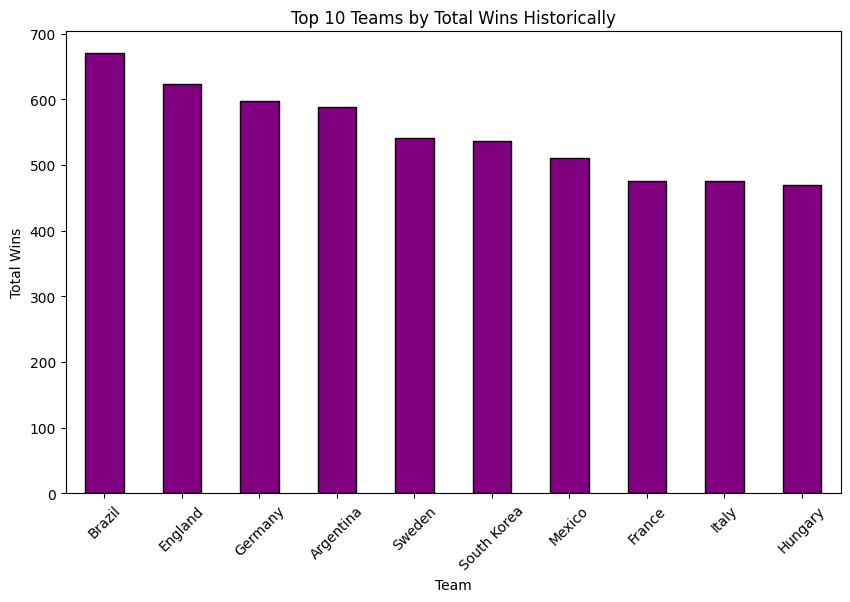

In [6]:
import matplotlib.pyplot as plt

# 1. Histogram of goals
plt.figure(figsize=(8, 5))
df["total_goals"].hist(bins=15, color='skyblue', edgecolor='black')
plt.title("Distribution of Goals Per Match")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.show()

# 2. Bar chart of match outcomes
plt.figure(figsize=(8, 5))
df["result"].value_counts().plot(kind='bar', color=['green', 'red', 'gray'], edgecolor='black')
plt.title("Match Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.show()

# 3. Top 10 teams by total wins
plt.figure(figsize=(10, 6))
# Re-using the total_wins series we calculated in the previous cell
total_wins.head(10).plot(kind='bar', color='purple', edgecolor='black')
plt.title("Top 10 Teams by Total Wins Historically")
plt.xlabel("Team")
plt.ylabel("Total Wins")
plt.xticks(rotation=45)
plt.show()